In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
print("Libraries imported succesfully")

Libraries imported succesfully


In [3]:
df = pd.read_csv('../data/processed/hotel_bookings_cleaned.csv')

print(f"Data loaded! Shape: {df.shape}")

Data loaded! Shape: (119390, 35)


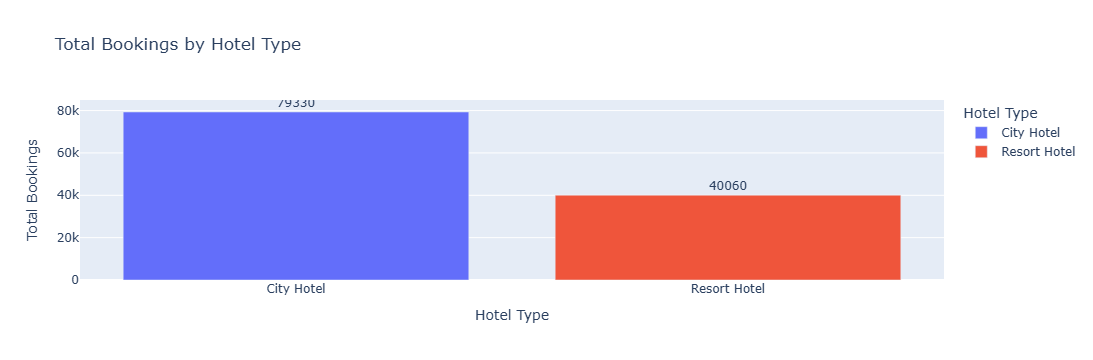

In [5]:
hotel_counts = df.groupby('hotel')['is_canceled'].agg(
 total_bookings='count',
 total_cancellations='sum'
).reset_index()

fig1 = px.bar(
hotel_counts,
x='hotel',
y='total_bookings',
color='hotel',
title='Total Bookings by Hotel Type',
labels={'hotel': 'Hotel Type', 'total_bookings': 'Total Bookings'},
text='total_bookings'
)

fig1.update_traces(textposition='outside')
fig1.show()

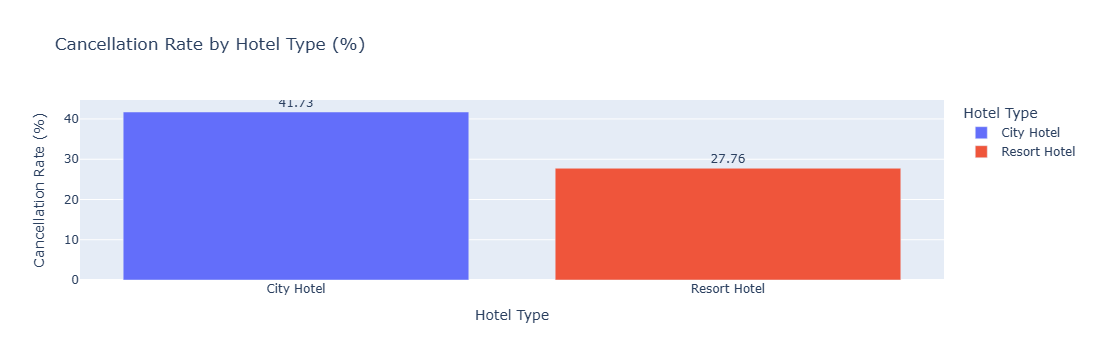

In [6]:
cancellation_by_hotel = df.groupby('hotel')['is_canceled'].mean().reset_index()
cancellation_by_hotel['cancellation_rate'] = round(cancellation_by_hotel['is_canceled'] * 100, 2)

fig2 = px.bar(
    cancellation_by_hotel,
    x='hotel',
    y='cancellation_rate',
    color='hotel',
    title='Cancellation Rate by Hotel Type (%)',
    labels={'hotel': 'Hotel Type', 'cancellation_rate': 'Cancellation Rate (%)'},
    text='cancellation_rate'
)

fig2.update_traces(textposition='outside')
fig2.show()

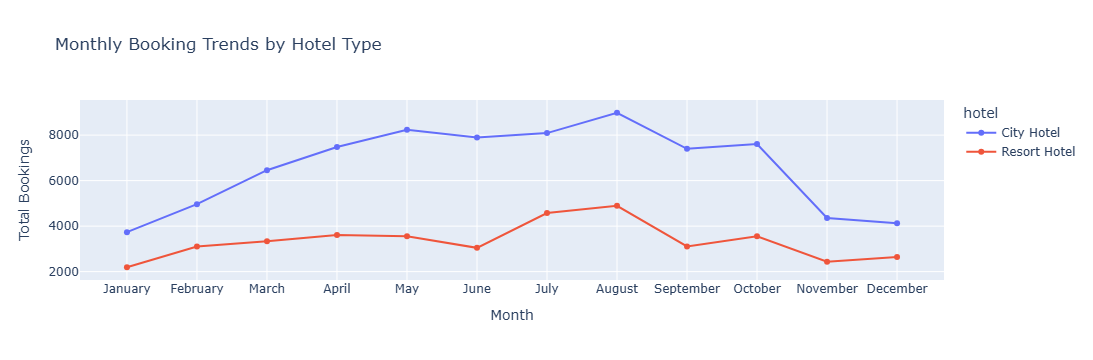

In [7]:
monthly = df.groupby(['arrival_month_num', 'arrival_date_month', 'hotel']).size().reset_index(name='total_bookings')
monthly = monthly.sort_values('arrival_month_num')

fig3 = px.line(
    monthly,
    x='arrival_date_month',
    y='total_bookings',
    color='hotel',
    title='Monthly Booking Trends by Hotel Type',
    labels={'arrival_date_month': 'Month', 'total_bookings': 'Total Bookings'},
    markers=True
)

fig3.show()

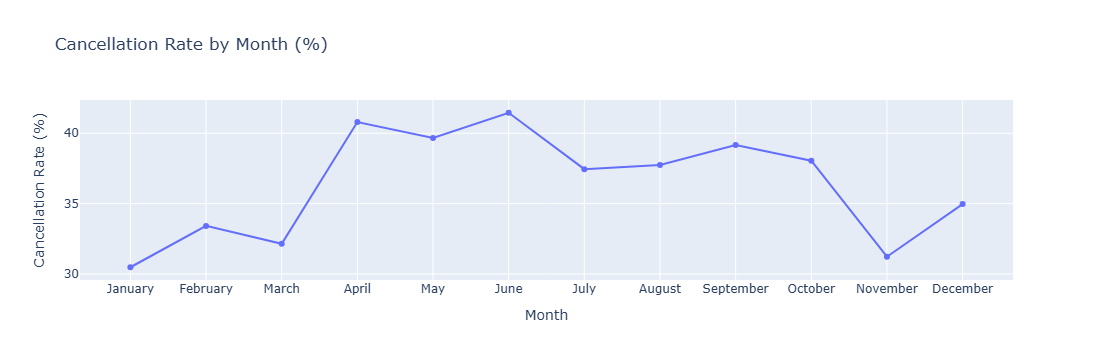

In [8]:
monthly_cancel = df.groupby(['arrival_month_num', 'arrival_date_month'])['is_canceled'].mean().reset_index()
monthly_cancel['cancellation_rate'] = round(monthly_cancel['is_canceled'] * 100, 2)
monthly_cancel = monthly_cancel.sort_values('arrival_month_num')

fig4 = px.line(
    monthly_cancel,
    x='arrival_date_month',
    y='cancellation_rate',
    title='Cancellation Rate by Month (%)',
    labels={'arrival_date_month': 'Month', 'cancellation_rate': 'Cancellation Rate (%)'},
    markers=True
)

fig4.show()

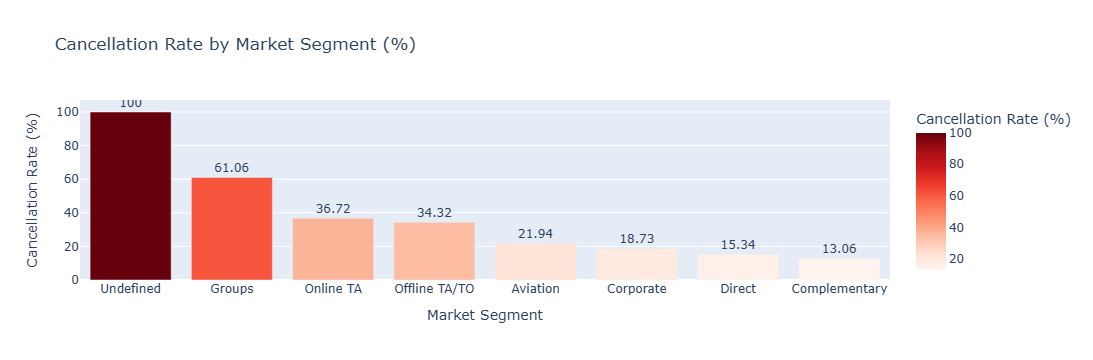

In [9]:
segment_cancel = df.groupby('market_segment')['is_canceled'].mean().reset_index()
segment_cancel['cancellation_rate'] = round(segment_cancel['is_canceled'] * 100, 2)
segment_cancel = segment_cancel.sort_values('cancellation_rate', ascending=False)

fig5 = px.bar(
    segment_cancel,
    x='market_segment',
    y='cancellation_rate',
    color='cancellation_rate',
    title='Cancellation Rate by Market Segment (%)',
    labels={'market_segment': 'Market Segment', 'cancellation_rate': 'Cancellation Rate (%)'},
    text='cancellation_rate',
    color_continuous_scale='Reds'
)

fig5.update_traces(textposition='outside')
fig5.show()

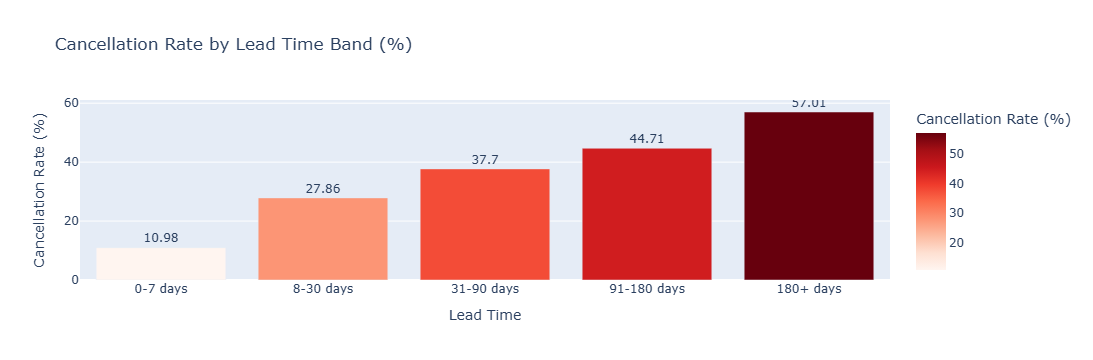

In [10]:
lead_time_cancel = df.copy()

lead_time_cancel['lead_time_band'] = pd.cut(
    df['lead_time'],
    bins=[0, 7, 30, 90, 180, 999],
    labels=['0-7 days', '8-30 days', '31-90 days', '91-180 days', '180+ days']
)

lead_cancel = lead_time_cancel.groupby('lead_time_band', observed=True)['is_canceled'].mean().reset_index()
lead_cancel['cancellation_rate'] = round(lead_cancel['is_canceled'] * 100, 2)

fig6 = px.bar(
    lead_cancel,
    x='lead_time_band',
    y='cancellation_rate',
    title='Cancellation Rate by Lead Time Band (%)',
    labels={'lead_time_band': 'Lead Time', 'cancellation_rate': 'Cancellation Rate (%)'},
    text='cancellation_rate',
    color='cancellation_rate',
    color_continuous_scale='Reds'
)

fig6.update_traces(textposition='outside')
fig6.show()

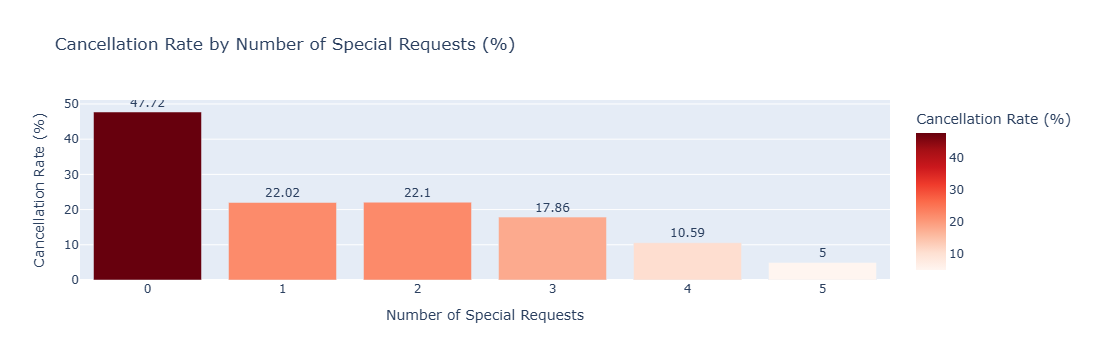

In [11]:
special_cancel = df.groupby('total_of_special_requests')['is_canceled'].mean().reset_index()
special_cancel['cancellation_rate'] = round(special_cancel['is_canceled'] * 100, 2)

fig7 = px.bar(
    special_cancel,
    x='total_of_special_requests',
    y='cancellation_rate',
    title='Cancellation Rate by Number of Special Requests (%)',
    labels={
        'total_of_special_requests': 'Number of Special Requests',
        'cancellation_rate': 'Cancellation Rate (%)'
    },
    text='cancellation_rate',
    color='cancellation_rate',
    color_continuous_scale='Reds'
)

fig7.update_traces(textposition='outside')
fig7.show()

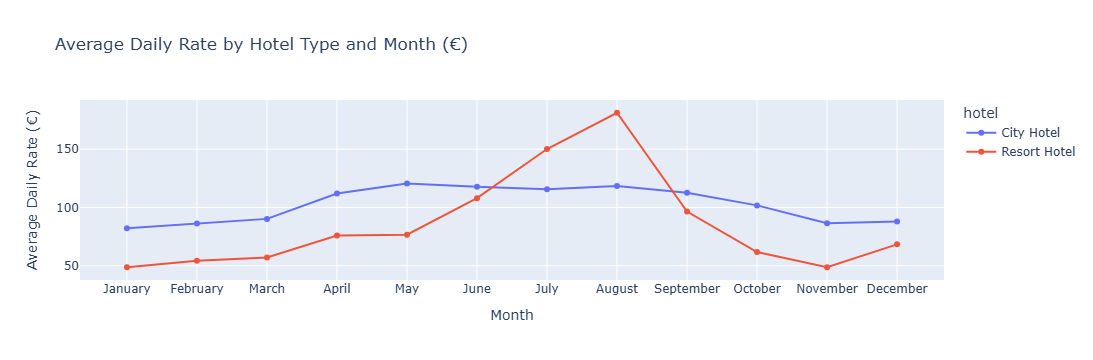

In [12]:
adr_monthly = df[df['is_canceled'] == 0].groupby(
    ['arrival_month_num', 'arrival_date_month', 'hotel']
)['adr'].mean().reset_index()

adr_monthly = adr_monthly.sort_values('arrival_month_num')
adr_monthly['adr'] = round(adr_monthly['adr'], 2)

fig8 = px.line(
    adr_monthly,
    x='arrival_date_month',
    y='adr',
    color='hotel',
    title='Average Daily Rate by Hotel Type and Month (€)',
    labels={'arrival_date_month': 'Month', 'adr': 'Average Daily Rate (€)'},
    markers=True
)

fig8.show()

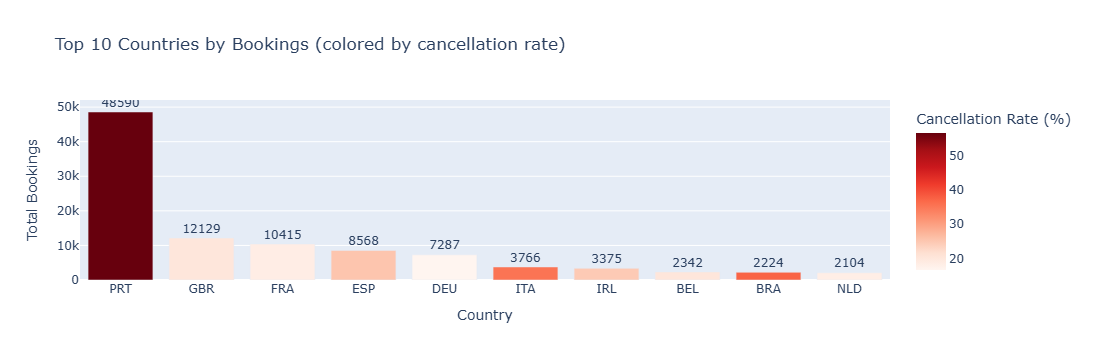

In [14]:
top_countries = df[df['country'] != 'Unknown'].groupby('country').agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean')
).reset_index()

top_countries['cancellation_rate'] = round(top_countries['cancellation_rate'] * 100, 2)
top_countries = top_countries.sort_values('total_bookings', ascending=False).head(10)

fig9 = px.bar(
    top_countries,
    x='country',
    y='total_bookings',
    color='cancellation_rate',
    title='Top 10 Countries by Bookings (colored by cancellation rate)',
    labels={'country': 'Country', 'total_bookings': 'Total Bookings', 'cancellation_rate': 'Cancellation Rate (%)'},
    text='total_bookings',
    color_continuous_scale='Reds'
)

fig9.update_traces(textposition='outside')
fig9.show()

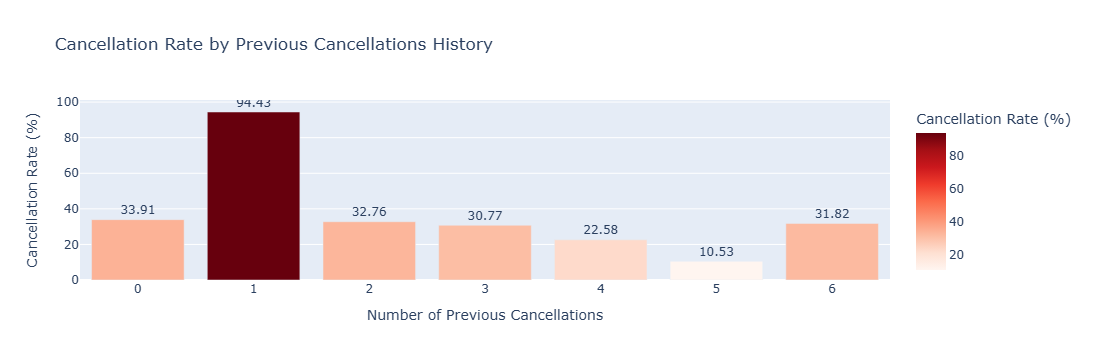

In [15]:
prev_cancel = df.groupby('previous_cancellations')['is_canceled'].mean().reset_index()
prev_cancel['cancellation_rate'] = round(prev_cancel['is_canceled'] * 100, 2)
prev_cancel = prev_cancel[prev_cancel['previous_cancellations'] <= 10]

fig10 = px.bar(
    prev_cancel,
    x='previous_cancellations',
    y='cancellation_rate',
    title='Cancellation Rate by Previous Cancellations History',
    labels={
        'previous_cancellations': 'Number of Previous Cancellations',
        'cancellation_rate': 'Cancellation Rate (%)'
    },
    text='cancellation_rate',
    color='cancellation_rate',
    color_continuous_scale='Reds'
)

fig10.update_traces(textposition='outside')
fig10.show()

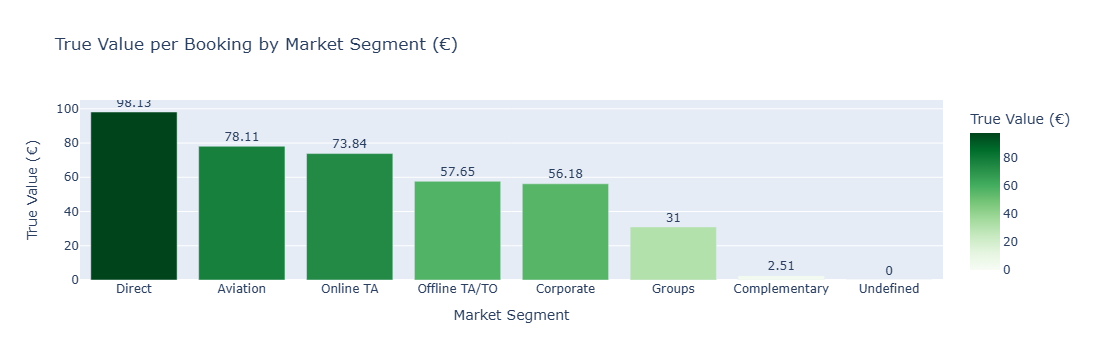

In [16]:
value_segment = df.groupby('market_segment').agg(
    avg_daily_rate=('adr', 'mean'),
    cancellation_rate=('is_canceled', 'mean')
).reset_index()

value_segment['avg_daily_rate'] = round(value_segment['avg_daily_rate'], 2)
value_segment['cancellation_rate'] = round(value_segment['cancellation_rate'], 2)
value_segment['true_value'] = round(
    value_segment['avg_daily_rate'] * (1 - value_segment['cancellation_rate']), 2
)

value_segment = value_segment.sort_values('true_value', ascending=False)

fig11 = px.bar(
    value_segment,
    x='market_segment',
    y='true_value',
    title='True Value per Booking by Market Segment (€)',
    labels={'market_segment': 'Market Segment', 'true_value': 'True Value (€)'},
    text='true_value',
    color='true_value',
    color_continuous_scale='Greens'
)

fig11.update_traces(textposition='outside')
fig11.show()

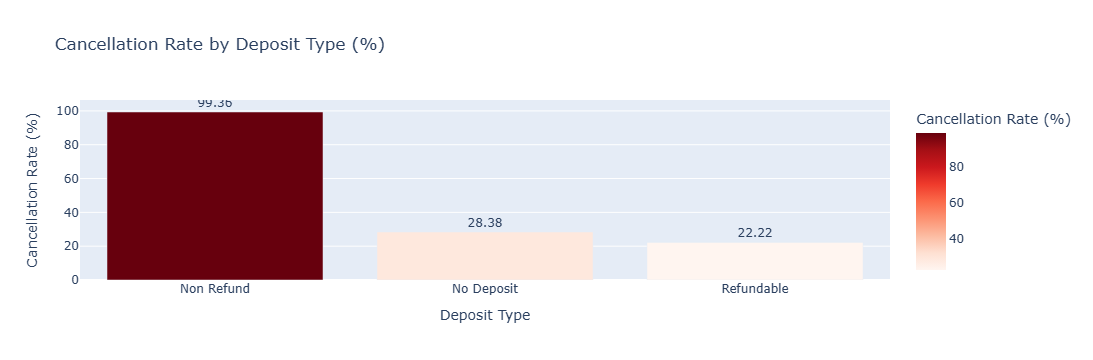

In [17]:
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean().reset_index()
deposit_cancel['cancellation_rate'] = round(deposit_cancel['is_canceled'] * 100, 2)
deposit_cancel = deposit_cancel.sort_values('cancellation_rate', ascending=False)

fig12 = px.bar(
    deposit_cancel,
    x='deposit_type',
    y='cancellation_rate',
    title='Cancellation Rate by Deposit Type (%)',
    labels={'deposit_type': 'Deposit Type', 'cancellation_rate': 'Cancellation Rate (%)'},
    text='cancellation_rate',
    color='cancellation_rate',
    color_continuous_scale='Reds'
)

fig12.update_traces(textposition='outside')
fig12.show()

In [18]:
import os

os.makedirs('../dashboards/screenshots', exist_ok=True)

fig1.write_html('../dashboards/screenshots/chart1_bookings_by_hotel.html')
fig2.write_html('../dashboards/screenshots/chart2_cancellation_by_hotel.html')
fig3.write_html('../dashboards/screenshots/chart3_monthly_trends.html')
fig4.write_html('../dashboards/screenshots/chart4_cancellation_by_month.html')
fig5.write_html('../dashboards/screenshots/chart5_cancellation_by_segment.html')
fig6.write_html('../dashboards/screenshots/chart6_cancellation_by_leadtime.html')
fig7.write_html('../dashboards/screenshots/chart7_cancellation_by_requests.html')
fig8.write_html('../dashboards/screenshots/chart8_adr_by_hotel_month.html')
fig9.write_html('../dashboards/screenshots/chart9_top_countries.html')
fig10.write_html('../dashboards/screenshots/chart10_previous_cancellations.html')
fig11.write_html('../dashboards/screenshots/chart11_true_value_segments.html')
fig12.write_html('../dashboards/screenshots/chart12_cancellation_by_deposit.html')

print("All 12 charts saved successfully!")

All 12 charts saved successfully!
